In [15]:
import pandas as pd

#file names
pos_file = "../../raw/cedar_positive.csv"
neg_file = "../../raw/cedar_negative.csv"

In [16]:
#load files
with open(pos_file, "r") as f: 
    first_line = f.readline() 
sep = "\t" if "\t" in first_line else ","

#read file
df_pos = pd.read_csv(pos_file, sep=sep, dtype=str)
df_neg = pd.read_csv(neg_file, sep=sep, dtype=str)

#add labels
df_pos["label"] = "Positive"
df_neg["label"] = "Negative"

#combine 
df = pd.concat([df_pos, df_neg], ignore_index=True)
df.head() 

,Epitope ID - CEDAR IRI,Epitope - Object Type,Epitope - Name,Epitope - Modified Residue(s),Epitope - Modifications,Epitope - Starting Position,Epitope - Ending Position,Epitope - IRI,Epitope - Synonyms,Epitope - Source Molecule,...,Related Object - Synonyms,Related Object - Source Molecule,Related Object - Source Molecule IRI,Related Object - Molecule Parent,Related Object - Molecule Parent IRI,Related Object - Source Organism,Related Object - Source Organism IRI,Related Object - Species,Related Object - Species IRI,label
0,https://cedar.iedb.org/epitope/551,Linear peptide,ACDPHSGHFV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"Cell division protein kinase 4, PSK-J3, CDK4",Cyclin-dependent kinase 4,https://www.uniprot.org/uniprot/P11802.2,Cyclin-dependent kinase 4,http://www.uniprot.org/uniprot/P11802,Homo sapiens (human),http://purl.obolibrary.org/obo/NCBITaxon_9606,Homo sapiens,http://purl.obolibrary.org/obo/NCBITaxon_9606,Positive
1,https://cedar.iedb.org/epitope/3147,Linear peptide,AMLGTHTMEV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,"immunoglobulin heavy chain junction region, pa...",http://www.ncbi.nlm.nih.gov/protein/MCC79800.1,NaN,NaN,Homo sapiens (human),http://purl.obolibrary.org/obo/NCBITaxon_9606,Homo sapiens,http://purl.obolibrary.org/obo/NCBITaxon_9606,Positive
2,https://cedar.iedb.org/epitope/4966,Linear peptide,ATGFKQSSK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"(1:Renal carcinoma antigen NY-REN-26, BCR, BCR...",Tyrosine-protein kinase ABL1,https://www.uniprot.org/uniprot/P00519.4,Tyrosine-protein kinase ABL1,http://www.uniprot.org/uniprot/P00519,Homo sapiens (human),http://purl.obolibrary.org/obo/NCBITaxon_9606,Homo sapiens,http://purl.obolibrary.org/obo/NCBITaxon_9606,Positive
3,https://cedar.iedb.org/epitope/14672,Linear peptide,EVDPIGHLY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,melanoma antigen 2; cancer/testis antigen fami...,melanoma-associated antigen 2 [Homo sapiens],http://www.ncbi.nlm.nih.gov/protein/NP_0012694...,Melanoma-associated antigen 2,http://www.uniprot.org/uniprot/P43356,Homo sapiens (human),http://purl.obolibrary.org/obo/NCBITaxon_9606,Homo sapiens,http://purl.obolibrary.org/obo/NCBITaxon_9606,Positive
4,https://cedar.iedb.org/epitope/19558,Linear peptide,GFKQSSKAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"(1:bcr), (2:Abelson murine leukemia viral onco...",Tyrosine-protein kinase ABL1,https://www.uniprot.org/uniprot/P00519.4,Tyrosine-protein kinase ABL1,http://www.uniprot.org/uniprot/P00519,Homo sapiens (human),http://purl.obolibrary.org/obo/NCBITaxon_9606,Homo sapiens,http://purl.obolibrary.org/obo/NCBITaxon_9606,Positive


In [17]:
#normalize column names

df.columns = (df.columns
              .str.replace(" - ", "_")
              .str.replace(" ", "_")
              .str.lower())

print(df.columns)

Index(['epitope_id_cedar_iri', 'epitope_object_type', 'epitope_name',
       'epitope_modified_residue(s)', 'epitope_modifications',
       'epitope_starting_position', 'epitope_ending_position', 'epitope_iri',
       'epitope_synonyms', 'epitope_source_molecule',
       'epitope_source_molecule_iri', 'epitope_molecule_parent',
       'epitope_molecule_parent_iri', 'epitope_source_organism',
       'epitope_source_organism_iri', 'epitope_species', 'epitope_species_iri',
       'epitope_mutation', 'related_object_epitope_relation',
       'related_object_object_type', 'related_object_name',
       'related_object_starting_position', 'related_object_ending_position',
       'related_object_iri', 'related_object_synonyms',
       'related_object_source_molecule', 'related_object_source_molecule_iri',
       'related_object_molecule_parent', 'related_object_molecule_parent_iri',
       'related_object_source_organism', 'related_object_source_organism_iri',
       'related_object_species', 

In [18]:
#pick relevant columns 
clean = pd.DataFrame()

clean["epitope_url"] = df["epitope_id_cedar_iri"] #to combine HLA
clean["mt_seq"] = df["epitope_name"].values
clean["wt_seq"] = df["related_object_name"].values
clean["mutation"] = df["epitope_mutation"].values
clean["epitope_relation"] = df["related_object_epitope_relation"].values
clean["source_molecule"] = df["epitope_source_molecule"].values
clean["label"] = df["label"].values

print(f'rows after combining: {len(clean)}')
clean.head()

rows after combining: 13346


,epitope_url,mt_seq,wt_seq,mutation,epitope_relation,source_molecule,label
0,https://cedar.iedb.org/epitope/551,ACDPHSGHFV,ARDPHSGHFV,R24C,in-frame neo-epitope,NaN,Positive
1,https://cedar.iedb.org/epitope/3147,AMLGTHTMEV,AMLSPHAMDV,NaN,in-frame neo-epitope,NaN,Positive
2,https://cedar.iedb.org/epitope/4966,ATGFKQSSK,b2a2,NaN,fusion neo-epitope,NaN,Positive
3,https://cedar.iedb.org/epitope/14672,EVDPIGHLY,EVVPISHLY,NaN,in-frame neo-epitope,NaN,Positive
4,https://cedar.iedb.org/epitope/19558,GFKQSSKAL,NaN,NaN,fusion neo-epitope,NaN,Positive


In [19]:
#uppercase and strip 
clean["mt_seq"] = clean["mt_seq"].str.strip().str.upper()
clean["wt_seq"] = clean["wt_seq"].str.strip().str.upper()

#drop rows with no peptide seq
clean = clean.dropna(subset=["mt_seq"]) 

print("after removing empty rows:", len(clean))

after removing empty rows: 13346


In [20]:
#filter out invalid aa
valid_aa = set("ACDEFGHIKLMNPQRSTVWY")

def is_valid(seq): 
    #reject missing 
    if not isinstance(seq, str): 
        return False
    #every aa must be valid 
    for aa in seq:
        if aa not in valid_aa: 
            return False
    return True

#keep only valid 
clean = clean[clean["mt_seq"].apply(is_valid)]
clean = clean[clean["wt_seq"].apply(is_valid)]
print("after filtering invalid aa:", len(clean))

after filtering invalid aa: 12740


In [21]:
#keep only inframe rows
clean = clean[clean["epitope_relation"].str.contains("in-frame", case=False, na=False)]
print("after filtering in-frame:", len(clean))

after filtering in-frame: 12265


In [22]:
#wildtype check
not_empty = clean["wt_seq"].notna()
valid_seq = clean["wt_seq"].apply(is_valid)

#combine
clean["has_wildtype"] = not_empty & valid_seq
print("after filtering wildtype:", len(clean))


after filtering wildtype: 12265


In [23]:
##REMOVE DUPLICATIONS

#positives per peptide
pos_count = {}

#if peptide is at least one time positive, then gets positive label 
for i, row in clean.iterrows(): 
    pep = row["mt_seq"]
    label = row["label"]
    if pep not in pos_count: 
        pos_count[pep] = 0
    if label == "Positive": 
        pos_count[pep] += 1

#drop duplicates
clean = clean.drop_duplicates(["mt_seq", "wt_seq"])

#assign final labels
new_labels = []
for pep in clean["mt_seq"]: 
    if pos_count[pep] > 0: 
        new_labels.append(1) #for ML 
    else: 
        new_labels.append(0)
clean["label"] = new_labels
print(f'final unique peptides: {len(clean)}')

final unique peptides: 11657


count    11657.000000
mean        16.166080
std          8.586156
min          8.000000
25%          9.000000
50%         10.000000
75%         25.000000
max         31.000000
Name: mt_length, dtype: float64


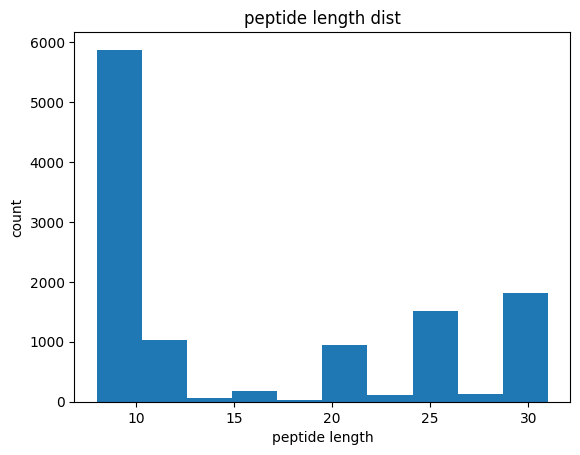

In [24]:
## PEPTIDE LENGTH ANALYSIS

clean["mt_length"] = clean["mt_seq"].str.len()
clean["wt_length"] = clean["wt_seq"].str.len()
print(clean["mt_length"].describe()) #same for wt

#histogram
import matplotlib.pyplot as plt 
plt.hist(clean["mt_length"], bins=10)
plt.xlabel("peptide length")
plt.ylabel("count")
plt.title("peptide length dist")
plt.show()

In [25]:
clean[clean["mt_length"] > 20][
    ["mt_seq", "epitope_relation"]
].head(10) #many overlapping peptides, filter out 

,mt_seq,epitope_relation
46,RKTVRARSRTPSCRSRSHTPSRRRR,in-frame neo-epitope
48,SWISDIRAGTAPLCRNHIKSSCSLI,in-frame neo-epitope
215,MTEYKLVVVGAVGVGKSALTIQLI,in-frame neo-epitope
340,GETCLLDILDTAGKEEYSAMRDQYMRT,in-frame neo-epitope
344,MTEYKLVVVGACGVGKSALTIQLIQNH,in-frame neo-epitope
345,MTEYKLVVVGADGVGKSALTIQLIQNH,in-frame neo-epitope
461,IDYHTLIANYMSWFLSLLTTANART,in-frame neo-epitope
624,DLRALRALHLDGNQLTSLGEGQLRGLV,in-frame neo-epitope
625,EIVPSPPSPPPLPHIYKPCFVCQDKSS,in-frame neo-epitope
626,FKVLCTTPNKYVVIDAAGAVKPQCCVD,in-frame neo-epitope


after length filter: 6868
label
0    4937
1    1931
Name: count, dtype: int64


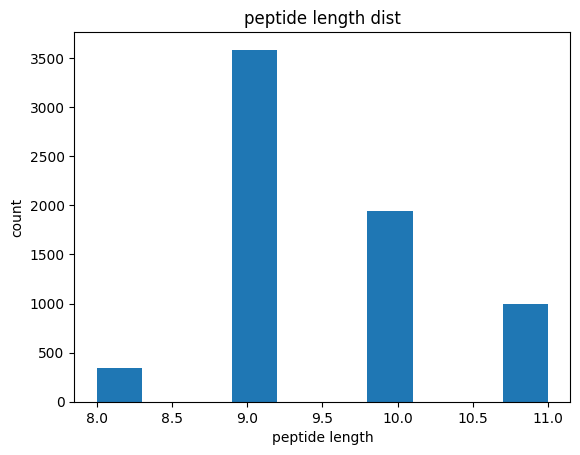

In [26]:
#FILTER OUT
#keep class i peptides only 
clean = clean[(clean["mt_length"] >=8) & (clean["mt_length"] <= 11)]
print("after length filter:", len(clean))
print(clean["label"].value_counts())
clean.head()

#histogram
import matplotlib.pyplot as plt 
plt.hist(clean["mt_length"], bins=10)
plt.xlabel("peptide length")
plt.ylabel("count")
plt.title("peptide length dist")
plt.show()

In [27]:
#save filtered dataset 
clean.to_csv("../../processed/cedar_filtered.csv", index=False)